# AIG100 - Machine Learning - Project 2
- This project is divided into two parts: classification algorithms and regression algorithms. For each part, I will process with data exploration and analysis (EDA) etc, until proceed through model training, evaluation, and horizontal performance comparisons among several algorithms. Different datasets will be used for the classification and regression tasks to ensure targeted analysis and comprehensive model assessment.

## Part 1 : Classification

### 1.1 Problem definition & objective setting

- Implement the entire data preparation process and train a classification model on a specific dataset.
- Train the model using several different classification algorithms.
- Compare the performance of the different models.

### 1.2 Data collection & integration
- **Datasource**: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
- **Data General Intro**: In this study, we use the CDC Diabetes Health Indicators dataset from the UCI Machine Learning Repository. The dataset contains health care statistics and lifestyle survey information collected from 253,680 individuals in the United States, based on the Behavioral Risk Factor Surveillance System (BRFSS). Each row corresponds to a single respondent, and the target variable Diabetes_binary indicates whether the person has diabetes or pre-diabetes (coded as 1) or is non-diabetic (coded as 0).
The dataset includes 21 predictive features capturing demographic characteristics (e.g., age groups, sex), health status (e.g., high blood pressure, high cholesterol, BMI), and lifestyle-related indicators (e.g., smoking, physical activity), most of which are binary or integer-coded. No missing values are reported in the processed version of the dataset, and some variables (such as age) have been discretized into buckets. This rich set of indicators enables us to model the relationship between health and lifestyle factors and the likelihood of having diabetes or pre-diabetes.

- **Variables Table**: we can find the viriables table and value descriptions for this dataset from above source site, for instance, for feature 'Sex', 0 = female 1 = male.

### 1.3 Exploratory data analysis (EDA)

#### Loading the data

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 
# Chi Squared
from scipy.stats import chi2_contingency

In [2]:
import pandas as pd

pdfile = pd.read_csv("./Classification/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
pdfile.head(20)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
5,0.0,0.0,0.0,1.0,18.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,2.0,7.0,0.0,0.0,0.0,1.0,4.0,7.0
6,0.0,0.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,13.0,5.0,6.0
7,0.0,0.0,0.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,6.0,4.0,3.0
8,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,6.0,8.0
9,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,6.0,0.0,1.0,6.0,4.0,4.0


In [3]:
pdfile.shape

(70692, 22)

#### Checking the data columns type

In [4]:
pdfile.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

#### Checking null values

In [5]:
pdfile.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

#### Checking statistics for all columns

In [6]:
pdfile.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


#### Checking unique values by columns

In [7]:
pdfile.nunique()

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

#### Checking duplicated rows

In [8]:
pdfile.duplicated().sum()

np.int64(1635)

#### Outlier Checking by IQR

In [9]:
numerical_cols = pdfile.select_dtypes(include="number").columns

def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[column] < lower) | (df[column] > upper)).sum()

outlier_summary = {
    col: count_outliers_iqr(pdfile, col)
    for col in numerical_cols
}

print("Number of outliers per numerical column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Number of outliers per numerical column:
Diabetes_binary: 0
HighBP: 0
HighChol: 0
CholCheck: 1749
BMI: 2181
Smoker: 0
Stroke: 4395
HeartDiseaseorAttack: 10449
PhysActivity: 0
Fruits: 0
Veggies: 14932
HvyAlcoholConsump: 3020
AnyHealthcare: 3184
NoDocbcCost: 6639
GenHlth: 0
MentHlth: 11816
PhysHlth: 10624
DiffWalk: 0
Sex: 0
Age: 0
Education: 0
Income: 0


#### Checking the distribution of each numeric columns

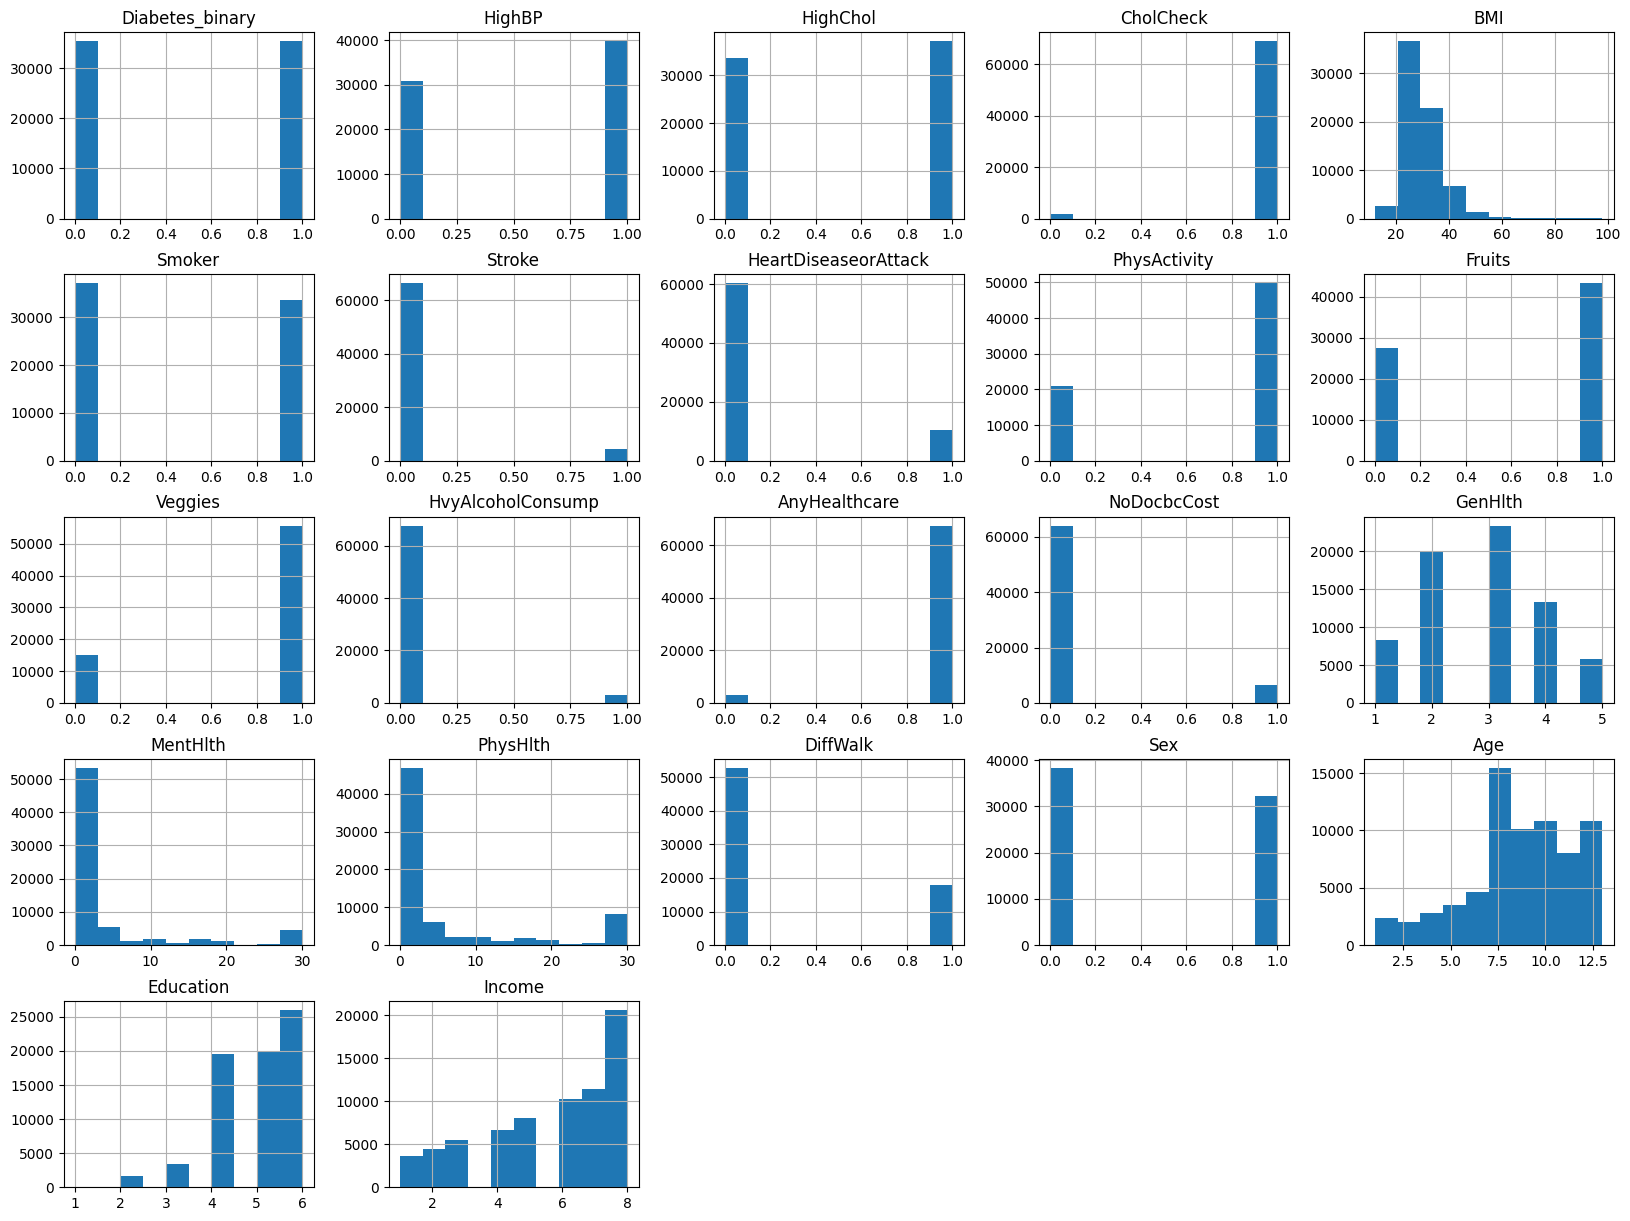

In [10]:
pdfile.hist(figsize = (20,15))
plt.show()

#### Columns Correlation check

In [11]:
corr = pdfile.corr(numeric_only=True)

corr_target = corr['Diabetes_binary'].sort_values(ascending=False)
corr_target


Diabetes_binary         1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64

#### Chi2 Square Test for all categorical columns

In [12]:
cat_cols = pdfile.select_dtypes(include='number').columns
cat_cols = [c for c in cat_cols if c != 'Diabetes_binary']

print("Chi-Squared Test: categorical features vs Diabetes_binary\n")

results = []

for col in cat_cols:
    ct = pd.crosstab(pdfile[col], pdfile['Diabetes_binary'])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    results.append((col, chi2, p, dof))
    print(f"{col:<12}  Chi2 = {chi2:8.2f}   p = {p:.3e}")

Chi-Squared Test: categorical features vs Diabetes_binary

HighBP        Chi2 = 10287.97   p = 0.000e+00
HighChol      Chi2 =  5911.81   p = 0.000e+00
CholCheck     Chi2 =   939.63   p = 2.380e-206
BMI           Chi2 =  7771.02   p = 0.000e+00
Smoker        Chi2 =   522.48   p = 1.221e-115
Stroke        Chi2 =  1111.08   p = 1.291e-243
HeartDiseaseorAttack  Chi2 =  3161.72   p = 0.000e+00
PhysActivity  Chi2 =  1778.96   p = 0.000e+00
Fruits        Chi2 =   206.50   p = 7.967e-47
Veggies       Chi2 =   444.08   p = 1.401e-98
HvyAlcoholConsump  Chi2 =   635.09   p = 3.913e-140
AnyHealthcare  Chi2 =    37.80   p = 7.856e-10
NoDocbcCost   Chi2 =   118.42   p = 1.405e-27
GenHlth       Chi2 = 12304.32   p = 0.000e+00
MentHlth      Chi2 =   655.05   p = 1.120e-118
PhysHlth      Chi2 =  3683.49   p = 0.000e+00
DiffWalk      Chi2 =  5253.69   p = 0.000e+00
Sex           Chi2 =   139.26   p = 3.860e-32
Age           Chi2 =  6179.06   p = 0.000e+00
Education     Chi2 =  2132.27   p = 0.000e+00
In

#### Finding from Chi2 squared test
- We applied chi-square tests to assess the association between each categorical feature and Diabetes_binary.
- All tested features show statistically significant associations with Diabetes_binary (p-values ≈ 0).
- Features with the strongest associations (largest chi-square statistics) are GenHlth, HighBP, BMI, Age, DiffWalk, PhysHlth, HeartDiseaseorAttack, HighChol, Income and Education.
- These results indicate that overall health status, comorbidities, body weight, age and socioeconomic status differ strongly between individuals with and without diabetes.
- Lifestyle-related features such as PhysActivity, Smoker, HvyAlcoholConsump, Fruits, Veggies and MentHlth are also significantly associated with Diabetes_binary, but with slightly weaker chi-square statistics.
- Variables related to healthcare access and demographics, including AnyHealthcare, NoDocbcCost, Sex and CholCheck, have statistically significant but comparatively weaker associations with Diabetes_binary.

#### Summary for EDA stage
- The dataset is clean, no missing values
- There are few duplicated rows, should be removed in data cleaning stage.
- All 21 feature variables and the target variable (diabetes_binary) were confirmed to be numeric
- The data distribution of target column is balanced. For some of columns are unbalanced, for instance, the data distribution of columns "BMI Histagram" is right-skewed
- From the Chi2 square test result, we can find columns associated with the target column diabetes_binary.
- We could remove 4 columns from the dataset - AnyHealthcare, NoDocbcCost, Sex and CholCheck, due to low associations with target variable Diabetes_binary. 

### 1.4 Data cleaning & preprocessing

#### Cleaning the duplicated data

In [13]:
pdfile.drop_duplicates(inplace = True)
pdfile.duplicated().sum()

np.int64(0)

#### Remove 4 columns

In [14]:
pdfile.drop(columns=['AnyHealthcare', 'NoDocbcCost', 'Sex', 'CholCheck'], inplace=True)

#### Summary for Data Cleaning and preprocessing stage
- Removed duplicated data, around 1635 rows
- Removed 4 columns from dataset 

### 1.5 Feature engineering

In [15]:
pdfile.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Age                     float64
Education               float64
Income                  float64
dtype: object

#### Cut the BMI column to 6 bins

In [16]:
pdfile['BMI_cat'] = pd.cut(
    pdfile['BMI'],
    bins=[0, 18.5, 25, 30, 35, 40, 200],
    labels=['underweight', 'normal', 'overweight',
            'obese_I', 'obese_II', 'obese_III']
)


pdfile = pd.get_dummies(
    pdfile,
    columns=['BMI_cat'],
    drop_first=False,
    dtype=int
)


In [17]:
pdfile.head(20)

,Diabetes_binary,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,DiffWalk,Age,Education,Income,BMI_cat_underweight,BMI_cat_normal,BMI_cat_overweight,BMI_cat_obese_I,BMI_cat_obese_II,BMI_cat_obese_III
0,0.0,1.0,0.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,4.0,6.0,8.0,0,0,1,0,0,0
1,0.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,12.0,6.0,8.0,0,0,1,0,0,0
2,0.0,0.0,0.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,13.0,6.0,8.0,0,0,1,0,0,0
3,0.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,11.0,6.0,8.0,0,0,1,0,0,0
4,0.0,0.0,0.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,8.0,5.0,8.0,0,0,1,0,0,0
5,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,4.0,7.0,1,0,0,0,0,0
6,0.0,0.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,13.0,5.0,6.0,0,0,1,0,0,0
7,0.0,0.0,0.0,31.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,6.0,4.0,3.0,0,0,0,1,0,0
8,0.0,0.0,0.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,3.0,6.0,8.0,0,0,0,1,0,0
9,0.0,0.0,0.0,27.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,6.0,4.0,4.0,0,0,1,0,0,0


In [18]:
pdfile.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Age                     float64
Education               float64
Income                  float64
BMI_cat_underweight       int64
BMI_cat_normal            int64
BMI_cat_overweight        int64
BMI_cat_obese_I           int64
BMI_cat_obese_II          int64
BMI_cat_obese_III         int64
dtype: object

#### Summary for feature engineering stage
- To make the classification more reasonable, I cut BMI into six bins and encoded them using one-hot .

### 1.6 Dataset splitting (train/test set)

In [19]:
from sklearn.model_selection import train_test_split

X = pdfile.drop(columns=['Diabetes_binary'])
y = pdfile['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 1.7 Model selection & training

#### 1.7.1 Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf, digits=4))


=== Random Forest ===
Accuracy: 0.7223428902403707
F1-score: 0.738243123336291
ROC-AUC: 0.7932858101033896
              precision    recall  f1-score   support

         0.0     0.7392    0.6727    0.7044      6792
         1.0     0.7087    0.7704    0.7382      7020

    accuracy                         0.7223     13812
   macro avg     0.7239    0.7215    0.7213     13812
weighted avg     0.7237    0.7223    0.7216     13812



#### Finding
- For the Random Forest classifier, the model achieved an accuracy of 0.72 on the test set, with an F1-score of 0.74 for the positive class and a ROC-AUC of 0.79. 

#### 1.7.2 XGBoost

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))


=== XGBoost ===
Accuracy: 0.7458731537793223
F1-score: 0.7608666030794387
ROC-AUC: 0.8213504806224183
              precision    recall  f1-score   support

         0.0     0.7667    0.6946    0.7289      6792
         1.0     0.7292    0.7954    0.7609      7020

    accuracy                         0.7459     13812
   macro avg     0.7479    0.7450    0.7449     13812
weighted avg     0.7476    0.7459    0.7451     13812



#### Findings
- For the XGBoost classifier, the model achieved an accuracy of 0.75 on the test set, with an F1-score of 0.76 for the positive class and a ROC-AUC of 0.82.

#### 1.7.3 SVM

In [22]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

svm_clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

svm_clf.fit(X_train[num_cols], y_train)

y_pred_svm = svm_clf.predict(X_test[num_cols])
y_proba_svm = svm_clf.predict_proba(X_test[num_cols])[:, 1]

print("=== SVM (RBF) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_svm))
print(classification_report(y_test, y_pred_svm, digits=4))


=== SVM (RBF) ===
Accuracy: 0.7419635099913119
F1-score: 0.7582745523602822
ROC-AUC: 0.8057074331625275
              precision    recall  f1-score   support

         0.0     0.7651    0.6858    0.7233      6792
         1.0     0.7237    0.7963    0.7583      7020

    accuracy                         0.7420     13812
   macro avg     0.7444    0.7411    0.7408     13812
weighted avg     0.7441    0.7420    0.7411     13812



#### Findings
- For the SVM with an RBF kernel, the model achieved an accuracy of 0.74, an F1-score of 0.76 for the positive class, and a ROC-AUC of 0.81. This indicates strong predictive performance, slightly below XGBoost but still competitive, with a good balance between precision and recall for the positive class.



#### 1.7.4 KNN

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

knn_clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=15))
])

knn_clf.fit(X_train[num_cols], y_train)

y_pred_knn = knn_clf.predict(X_test[num_cols])
y_proba_knn = knn_clf.predict_proba(X_test[num_cols])[:, 1]

print("=== KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))
print(classification_report(y_test, y_pred_knn, digits=4))


=== KNN ===
Accuracy: 0.7237185056472633
F1-score: 0.7386301369863014
ROC-AUC: 0.7941092923130614
              precision    recall  f1-score   support

         0.0     0.7388    0.6779    0.7070      6792
         1.0     0.7113    0.7681    0.7386      7020

    accuracy                         0.7237     13812
   macro avg     0.7251    0.7230    0.7228     13812
weighted avg     0.7248    0.7237    0.7231     13812



#### Findings
- For the KNN classifier (k=15), the model achieved an accuracy of 0.72, an F1-score of 0.74 for the positive class, and a ROC-AUC of 0.79. These results indicate a reasonable ability to distinguish between individuals with and without diabetes, but the performance is slightly weaker than XGBoost and SVM and similar to that of Random Forest.

### 1.8 Model Comparison

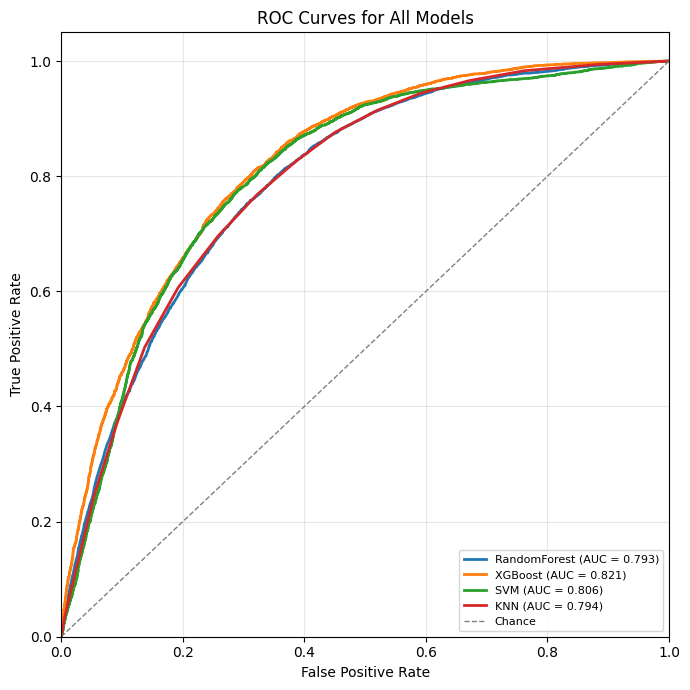

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 7))

models_proba = {
    "RandomForest": y_proba_rf,
    "XGBoost":      y_proba_xgb,
    "SVM":          y_proba_svm,
    "KNN":          y_proba_knn,
}

for name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1.9 Summary for Classification Practice

#### Summary
- We compared four classification models: Random Forest, XGBoost, SVM with an RBF kernel, and KNN. Overall, XGBoost achieved the best performance, with an accuracy of 0.75, an F1-score of 0.76 for the positive class, and a ROC-AUC of 0.82. The SVM model performed slightly worse than XGBoost but still competitively, reaching an accuracy of 0.74, an F1-score of 0.76, and a ROC-AUC of 0.81. Random Forest and KNN obtained similar performance levels, with accuracies around 0.72–0.72 and ROC-AUC values around 0.79.
#### Limitation
- During the model training, I encountered numerical compatibility issues between Python 3.13 / BLAS setup and several scikit-learn models. In particular, logistic regression, Naive Bayes, and the MLP classifier generated repeated runtime warnings related to matrix operations (such as divide-by-zero, overflow, and invalid values encountered in matrix multiplication), which are likely caused by low-level interactions between NumPy, BLAS libraries, and the specific Python version rather than by our model configuration. Because these numerical problems led to unstable behavior and unreliable evaluation metrics, I decided to remove these three models from the final comparison and focus on classifiers that ran robustly in our environment (Random Forest, XGBoost, SVM, and KNN).
- Another practical limitation concerns computational efficiency. While the SVM with an RBF kernel achieved competitive predictive performance, it was substantially slower to train and evaluate than the tree-based models and KNN on this dataset . This behavior is consistent with the known scalability issues of non-linear SVMs, whose training time typically grows superlinearly with both the number of samples and the dimensionality of the feature space, making them computationally expensive for large-scale problems.




## Part 2 : Regression

### 2.1 Problem definition & objective setting

- Implement the entire data preparation process and train a regression model on a specific dataset.
- Train and test the model using several different regression algorithms.
- Compare the performance of the different models.

### 2.2 Data collection & integration

- **Datasource**: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength
- **Data General Intro**: The Concrete Compressive Strength dataset comes from laboratory experiments on high-performance concrete mixtures. It is used to study how different ingredients and the age of the concrete affect its final strength. The dataset contains 1,030 observations, each representing one concrete sample. For every sample, there are eight numerical input variables: the amounts of cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate (all in kg per cubic meter), and the curing age in days. The target variable is the concrete’s compressive strength, measured in megapascals (MPa), which is a key property for civil engineering design. The data have no missing values and are given in raw form, so they are well suited for regression tasks, model comparison, and studying nonlinear relationships between mix design and strength.

### 2.3 Exploratory data analysis (EDA)

#### 2.3.1 Loading the data

In [25]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 


In [26]:
import pandas as pd

pdfile = pd.read_excel("./Regression/Concrete_Data.xls")
pdfile.head(20)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


#### Rename the column name

In [27]:
pdfile = pdfile.rename(columns={'Cement (component 1)(kg in a m^3 mixture)':'Cement',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)':'BFS',
       'Fly Ash (component 3)(kg in a m^3 mixture)':'Fly_Ash',
       'Water  (component 4)(kg in a m^3 mixture)':'Water',
       'Superplasticizer (component 5)(kg in a m^3 mixture)':'Superplasticizer',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)':'Coarser_agg',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)':'Fine_agg',
       'Age (day)':'Days',
       'Concrete compressive strength(MPa, megapascals) ':'Comp_str'})

In [28]:
pdfile.head(20)

,Cement,BFS,Fly_Ash,Water,Superplasticizer,Coarser_agg,Fine_agg,Days,Comp_str
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


#### 2.3.2 Checking the datatype

In [29]:
pdfile.dtypes

Cement              float64
BFS                 float64
Fly_Ash             float64
Water               float64
Superplasticizer    float64
Coarser_agg         float64
Fine_agg            float64
Days                  int64
Comp_str            float64
dtype: object

In [30]:
pdfile.shape

(1030, 9)

#### 2.3.3 Checking the missing values

In [31]:
pdfile.isnull().sum()

Cement              0
BFS                 0
Fly_Ash             0
Water               0
Superplasticizer    0
Coarser_agg         0
Fine_agg            0
Days                0
Comp_str            0
dtype: int64

#### 2.3.4 Checking duplicated data

In [32]:
pdfile.duplicated().sum()

np.int64(25)

#### 2.3.5 Checking the statistics data for each column

In [33]:
pdfile.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
BFS,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
Fly_Ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
Coarser_agg,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
Fine_agg,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Days,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
Comp_str,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


#### 2.3.6 Checking unique value for each column

In [34]:
pdfile.nunique()

Cement              280
BFS                 187
Fly_Ash             163
Water               205
Superplasticizer    155
Coarser_agg         284
Fine_agg            304
Days                 14
Comp_str            938
dtype: int64

#### 2.3.7 Checking the data outlier by IQR

In [35]:
numerical_cols = pdfile.select_dtypes(include="number").columns

def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[column] < lower) | (df[column] > upper)).sum()

outlier_summary = {
    col: count_outliers_iqr(pdfile, col)
    for col in numerical_cols
}

print("Number of outliers per numerical column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Number of outliers per numerical column:
Cement: 0
BFS: 2
Fly_Ash: 0
Water: 9
Superplasticizer: 10
Coarser_agg: 0
Fine_agg: 5
Days: 59
Comp_str: 4


#### 2.3.8 Checking the data distribution for each column

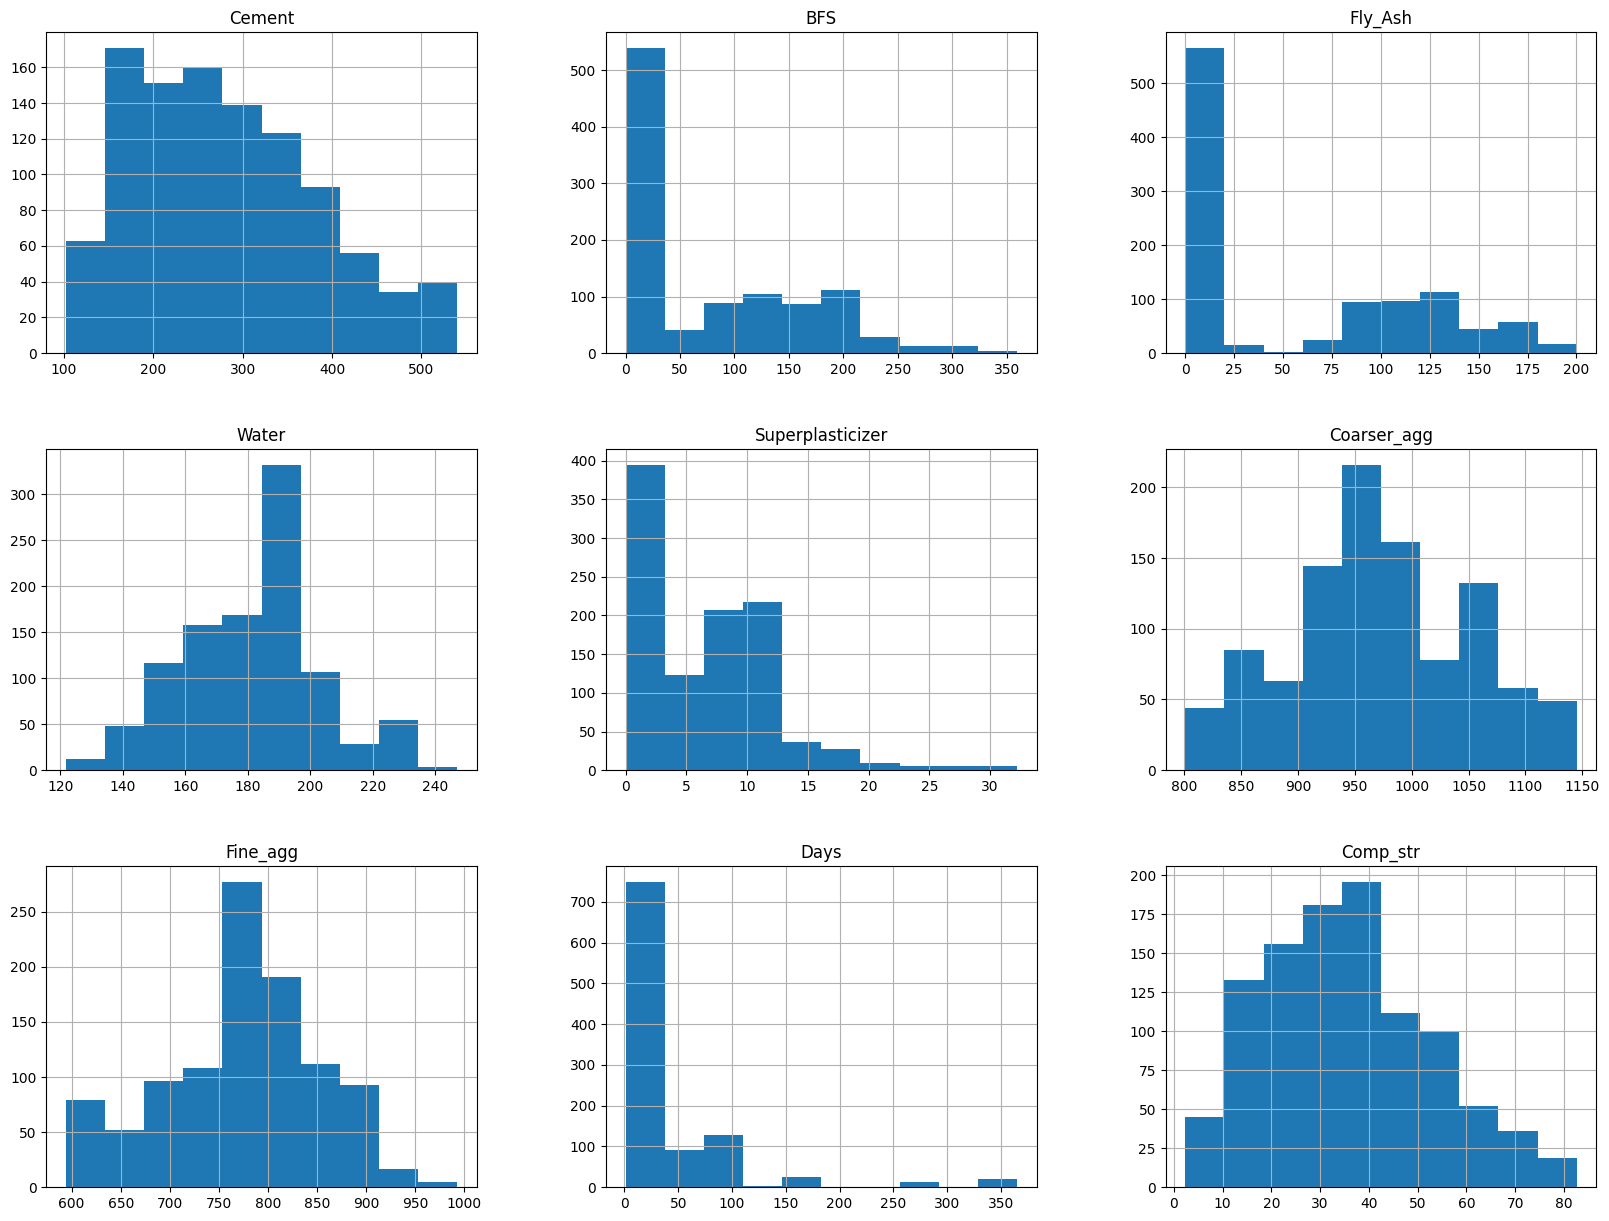

In [36]:
pdfile.hist(figsize = (20,15))
plt.show()

#### 2.3.9 Checking the correlationship between each numeric column and target column 'Concrete compresive strength'

In [37]:
corr = pdfile.corr(numeric_only=True)

corr_target = corr['Comp_str'].sort_values(ascending=False)
corr_target

Comp_str            1.000000
Cement              0.497833
Superplasticizer    0.366102
Days                0.328877
BFS                 0.134824
Fly_Ash            -0.105753
Coarser_agg        -0.164928
Fine_agg           -0.167249
Water              -0.289613
Name: Comp_str, dtype: float64

#### 2.3.10 Checking the f-regression value

In [38]:
from sklearn.feature_selection import SelectKBest, f_regression
pdfile2 = pdfile.copy()

X = pdfile2.drop(columns=["Comp_str"])
y = pdfile2["Comp_str"]

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)

f_scores = selector.scores_
p_values = selector.pvalues_

feature_scores = pd.DataFrame({
    "feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values,
}).sort_values(by="F_score", ascending=False)

print(feature_scores)


            feature     F_score       p_value
0            Cement  338.725794  1.323458e-65
4  Superplasticizer  159.109322  5.079089e-34
7              Days  124.673209  2.103144e-27
3             Water   94.118797  2.366073e-21
6          Fine_agg   29.582938  6.694681e-08
5       Coarser_agg   28.744710  1.019597e-07
1               BFS   19.032572  1.414575e-05
2           Fly_Ash   11.626949  6.752836e-04


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


#### Summary for EDA stage

- The dataset contains 1,030 rows and 9 numeric variables (8 input features and 1 target: Comp_str).
- There are no missing values
- Found a few duplicate rows
- Checked the data outlier by IQR, found very few outlier for several columns
- The data distribution for most of columns are left-skewed or right-skewed.
- Correlation and f_regression analysis indicate that cement, superplasticizer, days, and water are the most influential features for predicting Comp_str, while Fine_agg, Coarser_agg, BFS, and Fly_Ash have weaker but still significant linear effects. T-test and chi2 square test is not suitable to regression related dataset.
- Tried to remove warning message for f_regression test, but failed.

### 2.4 Data cleaning & preprocessing

In [39]:
pdfile.drop_duplicates()

,Cement,BFS,Fly_Ash,Water,Superplasticizer,Coarser_agg,Fine_agg,Days,Comp_str
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


#### Summary for data cleaning stage

- Deleted 25 duplicated rows 

### 2.5 Dataset splitting (train/test set)

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pdfile.copy()

X = df.drop(columns=["Comp_str"])
y = df["Comp_str"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)


#### Summary for dataset splitting stage
- For model evaluation, the dataset was randomly split into a training set and a test set using an 80/20 ratio. The training set was used to fit the regression models and to learn the feature scaling parameters, while the test set was kept completely separate.
- Feature standardization (z‑score scaling) was applied only after the split and was fitted on the training data, then reused to transform the test data. This procedure avoids data leakage and ensures that performance metrics on the test set provide an unbiased estimate of how the models will generalize to new concrete samples.

### 2.6 Model selection & training & comparison

In [41]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score

results = []

def eval_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"model": name, "RMSE": rmse, "R2": r2})

eval_model("LinearRegression",
           LinearRegression(),
           X_train_scaled, y_train, X_test_scaled, y_test)

eval_model("Ridge(alpha=1.0)",
           Ridge(alpha=1.0, random_state=42),
           X_train_scaled, y_train, X_test_scaled, y_test)

eval_model("Lasso(alpha=0.1)",
           Lasso(alpha=0.1, random_state=42),
           X_train_scaled, y_train, X_test_scaled, y_test)

eval_model("RandomForestRegressor",
           RandomForestRegressor(
               n_estimators=200,
               random_state=42,
               n_jobs=-1
           ),
           X_train_scaled, y_train, X_test_scaled, y_test)

eval_model("SVR(RBF)",
           SVR(kernel="rbf", C=10.0, epsilon=0.2),
           X_train_scaled, y_train, X_test_scaled, y_test)

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: Runti

                   model      RMSE        R2
3  RandomForestRegressor  5.557083  0.880157
4               SVR(RBF)  7.149784  0.801618
1       Ridge(alpha=1.0)  9.796411  0.627564
0       LinearRegression  9.796708  0.627542
2       Lasso(alpha=0.1)  9.819122  0.625835


#### Summary for Regression models training and comparison

- Several regression models were trained and evaluated on the concrete dataset using the same train–test split and standardized input features. Performance was measured on the test set using RMSE (in MPa) and R².
- RandomForestRegressor achieved the best results, with an RMSE of about 5.56 MPa and an R² of about 0.88. This shows that a non-linear tree ensemble can capture the complex relationships between mix ingredients, age, and compressive strength.
- SVR with an RBF kernel also performed well, with an RMSE of about 7.15 MPa and an R² of about 0.80, but it was clearly weaker than the random forest. The linear models (Linear Regression, Ridge, and Lasso) all gave similar results, with RMSE around 9.8 MPa and R² around 0.63, which indicates that purely linear models cannot fully explain the variance in strength for this dataset.
- Overall, RandomForestRegressor is the preferred model for prediction accuracy on this problem, while the linear models are more suitable as baseline models and for interpreting the approximate linear influence of each input variable.
- Those warning messages appeared again, just like 'divide by zero' or 'overflow encountered in matmul' etc.